# Search of near-duplicate images in datasets

**Problem** is that ML-models are usualy trained on datasets, where images are almost the identical. It wastes the budget for labeling and can impact model performance

**Goal** is to use AI embeddings + cosine similarity to find and remove near-duplicates, then visualize the impact on model training

We are going to use CIFAR-10 which is a dataset that has 60K images of planes, cats, cars and etc

## Step 1: Load Dataset

So how I said before, the dataset has 60K images, but for now, just to demostrate, I am going to use just 50K images, but the result will still be more diluted if the amount of data will be bigger

Also while writing code i saw that `total dataset size:50000`, so CIFAR-10 contains 60K of images in total, HOWEVER, 50K of them is training images and the rest 10K of them is Test Images

In [23]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from torch.utils.data import DataLoader, Subset
import warnings
warnings.filterwarnings('ignore')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

SIZE = 50000
subset = Subset(full_dataset, range(SIZE))
loader = DataLoader(subset, batch_size=256, shuffle=False)

classes = full_dataset.classes
print(f"total dataset size:{len(full_dataset)}")
print(f"working sample size:{SIZE}")
print(f"classes:{classes}")

total dataset size:50000
working sample size:50000
classes:['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Step 2: Visualize Images

So we loaded dataset, and now let's see what we have

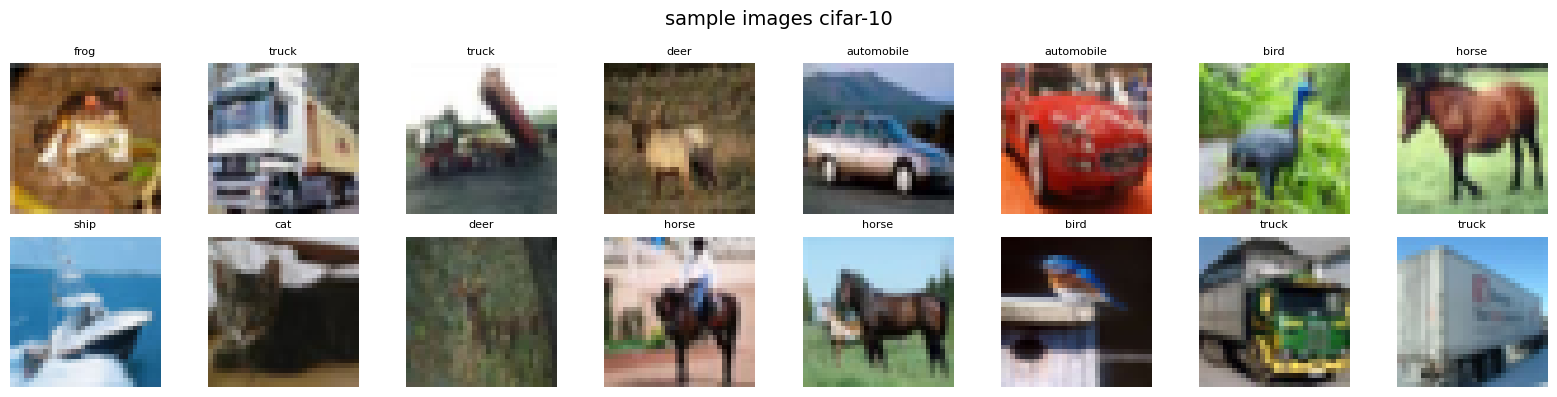

In [24]:
fig, axes = plt.subplots(2, 8, figsize=(16,4))
fig.suptitle("sample images cifar-10", fontsize=14)

for i, ax in enumerate(axes.flat):
    img, label = full_dataset[i]
    img = img.numpy().transpose(1,2,0)
    img = (img*0.5+0.5).clip(0,1)
    ax.imshow(img)
    ax.set_title(classes[label], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3: Generate Embedings

Embedding is a vector of numbers that represents an image. Basically, `similar images = similar vectors`

We use `ResNet18` which is pretrained on ImageNet as our encoder
We will remove its final classification layer so we can get 512-dimensional feature vector per image instead of class prediction

In [25]:
model = torchvision.models.resnet18(pretrained=True)
model.fc = torch.nn.Identity()
model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # i am working through codespaces in github, so i have no clue if i have cuda or cpu
model = model.to(device)
print(f"device:{device}")

device:cpu


In [26]:
all_embeddings = []
all_labels = []

with torch.no_grad():
    for i, (images, labels) in enumerate(loader):
        images = images.to(device)
        embeddings = model(images)
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.extend(labels.numpy())

        if i % 5 == 0:
            print(f"processed batch {i+1}/{len(loader)}")

all_embeddings = np.concatenate(all_embeddings, axis=0)
all_labels = np.array(all_labels)

print(f"\nembedding matrix shape:{all_embeddings.shape}")
print(f"each image is now a vector of {all_embeddings.shape[1]}")

processed batch 1/196
processed batch 6/196
processed batch 11/196
processed batch 16/196
processed batch 21/196
processed batch 26/196
processed batch 31/196
processed batch 36/196
processed batch 41/196
processed batch 46/196
processed batch 51/196
processed batch 56/196
processed batch 61/196
processed batch 66/196
processed batch 71/196
processed batch 76/196
processed batch 81/196
processed batch 86/196
processed batch 91/196
processed batch 96/196
processed batch 101/196
processed batch 106/196
processed batch 111/196
processed batch 116/196
processed batch 121/196
processed batch 126/196
processed batch 131/196
processed batch 136/196
processed batch 141/196
processed batch 146/196
processed batch 151/196
processed batch 156/196
processed batch 161/196
processed batch 166/196
processed batch 171/196
processed batch 176/196
processed batch 181/196
processed batch 186/196
processed batch 191/196
processed batch 196/196

embedding matrix shape:(50000, 512)
each image is now a vecto

# Step 4: Near-Duplicates

Cosine similarity measures the angle between two vectors
1.0 is identical
0.98 is near-duplicate
<0.8 is different

we normalize all vectors first and then compute pairwise similarity

In [27]:
emb_normalized = normalize(all_embeddings)

sim_matrix = cosine_similarity(emb_normalized)
print(f'similarity matrix shape:{sim_matrix.shape}')

THRESHOLD = 0.98
duplicates = set()

for i in range(len(sim_matrix)):
    for j in range(i + 1, len(sim_matrix)):
        if sim_matrix[i][j] > THRESHOLD:
            duplicates.add(j)

print(f"\nthreshold: {THRESHOLD}")
print(f"near-duplcates found:{len(duplicates)}")
print(f"unique images:{SIZE - len(duplicates)}")
print(f"reduction:{len(duplicates)/SIZE*100:.1f}%")

similarity matrix shape:(50000, 50000)

threshold: 0.98
near-duplcates found:176
unique images:49824
reduction:0.4%


## Step 5: Visualize Duplicate Pairs

Now let's see at some near-duplicate pairs we found. Our model consider this images are near-duplicate

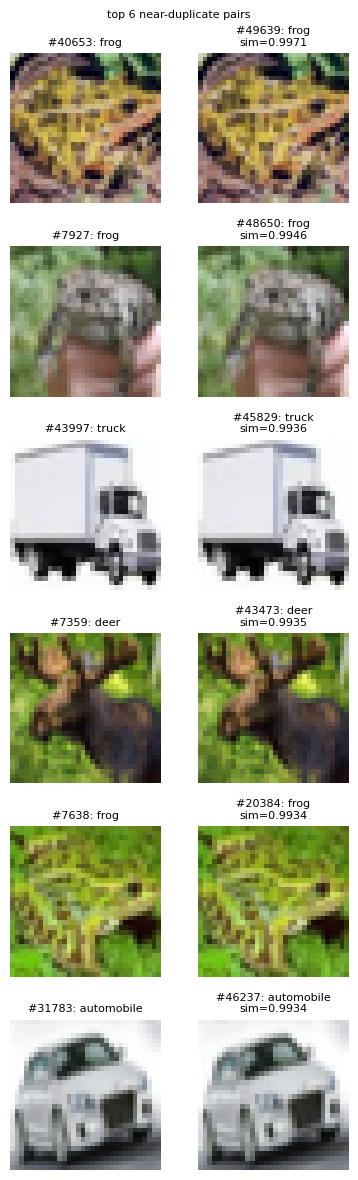

In [28]:
duplicate_pairs = []

for i in range(len(sim_matrix)):
    for j in range(i+1, len(sim_matrix)):
        if sim_matrix[i][j] > THRESHOLD:
            duplicate_pairs.append((i, j, sim_matrix[i][j]))

duplicate_pairs.sort(key=lambda x: x[2], reverse=True)

def get_image(idx):
    img, label = full_dataset[idx]
    img = img.numpy().transpose(1,2,0)
    img = (img * 0.5 +0.5).clip(0,1)
    return img, label

n_show = min(6, len(duplicate_pairs))

if n_show == 0:
    print(f"no duplicates found at {THRESHOLD}")
else:
    fig, axes = plt.subplots(n_show, 2, figsize=(4, n_show*2))
    fig.suptitle(f"top {n_show} near-duplicate pairs", fontsize=8)
    
    for row, (i, j, score) in enumerate(duplicate_pairs[:n_show]):
        img_i, label_i = get_image(i)
        img_j, label_j = get_image(j)

        axes[row, 0].imshow(img_i)
        axes[row, 0].set_title(f"#{i}: {classes[label_i]}", fontsize=8)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(img_i)
        axes[row, 1].set_title(f"#{j}: {classes[label_j]}\nsim={score:.4f}", fontsize=8)
        axes[row, 1].axis('off')
    
    plt.tight_layout()
    plt.savefig('duplicate_pairs.png', dpi=150, bbox_inches='tight')
    plt.show

## Step 6: Visualize Embedding Space

UMAP is going to compress 512 dimensional vectors down to 2D so we can plot them. Similar images are identified if points close together

Red points are near-duplicates found by algo and Blue points are unique images

In [29]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
emb_2d = reducer.fit_transform(emb_normalized)
print('umap finished')


umap finished


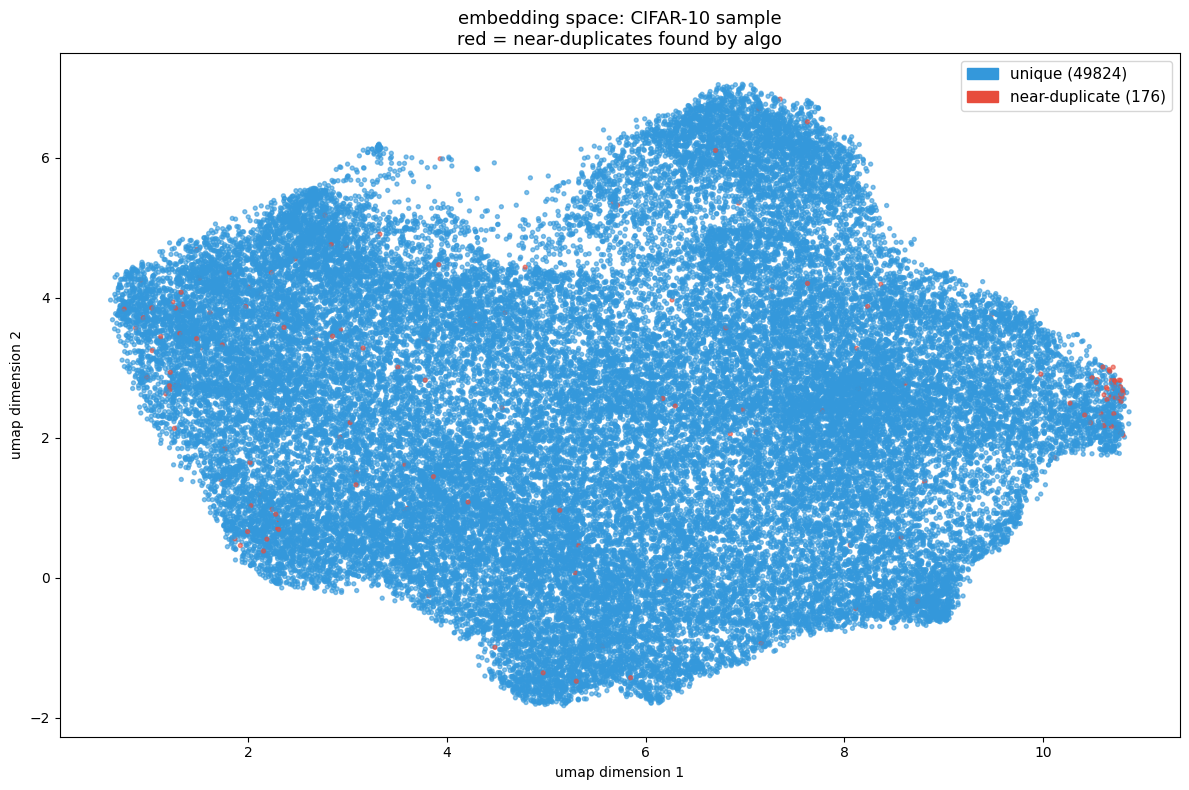

In [30]:
colors = ['#e74c3c' if i in duplicates else '#3498db' for i in range(SIZE)]

plt.figure(figsize=(12, 8))
plt.scatter(emb_2d[:,0], emb_2d[:, 1],
            c=colors, alpha=0.6, s=8)

from matplotlib.patches import Patch
legend = [
    Patch(color='#3498db', label=f'unique ({SIZE - len(duplicates)})'),
    Patch(color='#e74c3c', label=f'near-duplicate ({len(duplicates)})')
]
plt.legend(handles=legend, fontsize=11)
plt.title('embedding space: CIFAR-10 sample\nred = near-duplicates found by algo', fontsize=13)
plt.xlabel('umap dimension 1')
plt.ylabel('umap dimension 2')
plt.tight_layout()
plt.savefig('embedding_space.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Impact on Model Training

So now the question is, does removing near-duplicates actually help?

We train simple logistic regression classifier on original data and cleaned data, and then compare accuracy on a held-out test set.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

clean_indices = [i for i in range(SIZE) if i not in duplicates]

X_train_orig, X_test, y_train_orig, y_test = train_test_split(
    all_embeddings, all_labels,
    test_size=0.2, random_state=42
)

clean_emb = all_embeddings[clean_indices]
clean_labels = all_labels[clean_indices]
X_train_clean, _, y_train_clean, _ = train_test_split(
    clean_emb, clean_labels,
    test_size=0.2, random_state=42
)

print(f"original training set:{len(X_train_orig)} samples")
print(f"cleaned training set:{len(X_train_clean)} samples")
print(f"test set:{len(X_test)} samples (same for both)")
print(f"\ntraining models...")

original training set:40000 samples
cleaned training set:39859 samples
test set:10000 samples (same for both)

training models...


In [32]:
clf_orig = LogisticRegression(max_iter=1000, random_state=42)
clf_orig.fit(X_train_orig, y_train_orig)
acc_orig = accuracy_score(y_test, clf_orig.predict(X_test))

clf_clean = LogisticRegression(max_iter=1000, random_state=42)
clf_clean.fit(X_train_clean, y_train_clean)
acc_clean = accuracy_score(y_test, clf_clean.predict(X_test))

print(f"accuracy on original data:{acc_orig:.4f} ({acc_orig*100:.1f}%)")
print(f"accuracy on cleaned data:{acc_clean:.4f} ({acc_clean*100:.1f}%)")
print(f"\ndiff: {(acc_clean - acc_orig)*100:+0.2f}%")
print(f"data reduction:{(1-len(clean_indices)/SIZE)*100:.1f}%")

accuracy on original data:0.6590 (65.9%)
accuracy on cleaned data:0.6891 (68.9%)

diff: +3.01%
data reduction:0.4%


## Step 8: Summary

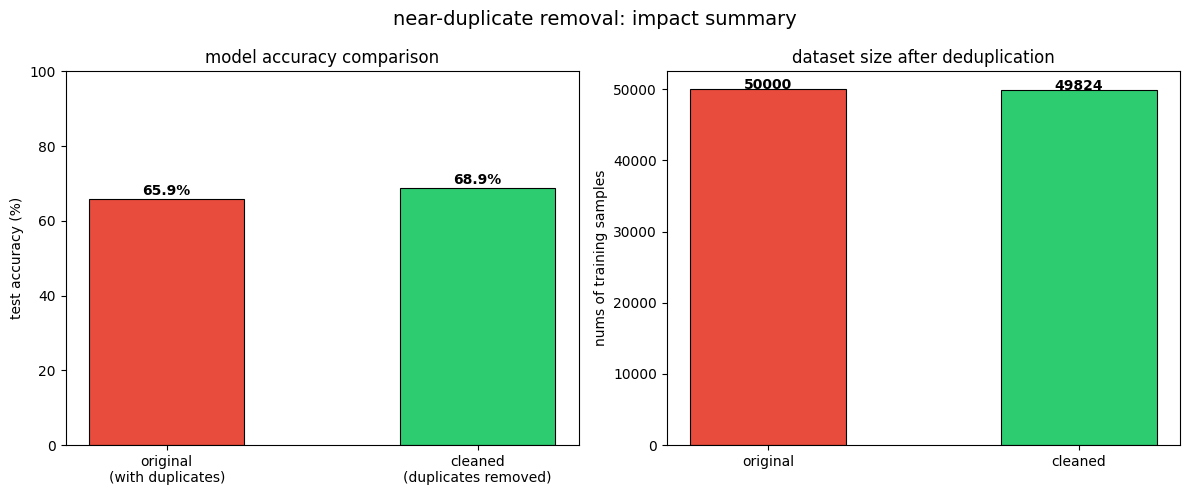

In [33]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

bars = axes[0].bar(
    ['original\n(with duplicates)', 'cleaned\n(duplicates removed)'],
    [acc_orig * 100, acc_clean * 100],
    color = ['#e74c3c', '#2ecc71'],
    width=0.5,
    edgecolor='black',
    linewidth=0.8
)
axes[0].set_ylabel('test accuracy (%)')
axes[0].set_title('model accuracy comparison')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, [acc_orig*100, acc_clean*100]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+1,
                 f'{val:.1f}%', ha='center', fontweight='bold')

axes[1].bar(
    ['original', 'cleaned'],
    [SIZE, len(clean_indices)],
    color = ['#e74c3c', '#2ecc71'],
    width=0.5,
    edgecolor='black',
    linewidth=0.8
)
axes[1].set_ylabel('nums of training samples')
axes[1].set_title('dataset size after deduplication')
for bar, val in zip(axes[1].patches, [SIZE, len(clean_indices)]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()+20,
                 str(val), ha='center', fontweight='bold')
    
plt.suptitle('near-duplicate removal: impact summary', fontsize=14)
plt.tight_layout()
plt.savefig("results_summary.png", dpi=150, bbox_inches='tight')
plt.show()


Holy moly, by just removing 176 near-duplicates (0.4% of 50,000 images) 
we improved accuracy of the model by +3.01% (65.9% → 68.9%)
For a big project with labeling of 1 million images for $0.05 
this approach could remove ~8,000 redundant samples and save ~$400 
while delivering a cleaner, more accurate model

Used: PyTorch, ResNet18, scikit-learn, UMAP
Dataset: CIFAR-10